In [ ]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [ ]:
#load the geyser dataset
import seaborn as sns

data = sns.load_dataset("geyser")

data.head()

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long


In [ ]:
#check the dataset
print(data.shape)
print(data.info())
print(data.isnull().sum())

(272, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duration  272 non-null    float64
 1   waiting   272 non-null    int64  
 2   kind      272 non-null    object 
dtypes: float64(1), int64(1), object(1)
memory usage: 6.5+ KB
None
duration    0
waiting     0
kind        0
dtype: int64


In [ ]:
#select 2 features
X = data[['duration', 'waiting']]

X.head()

,duration,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [ ]:
#create k-means model
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [ ]:
#get cluster labels and add cluster info
clusters = kmeans.labels_

print(clusters)
data['Cluster'] = clusters

data.head()

[0 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1
 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0
 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0
 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 0 1
 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1
 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 0 1 0
 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 0]


,duration,waiting,kind,Cluster
0,3.600,79,long,0
1,1.800,54,short,1
2,3.333,74,long,0
3,2.283,62,short,1
4,4.533,85,long,0


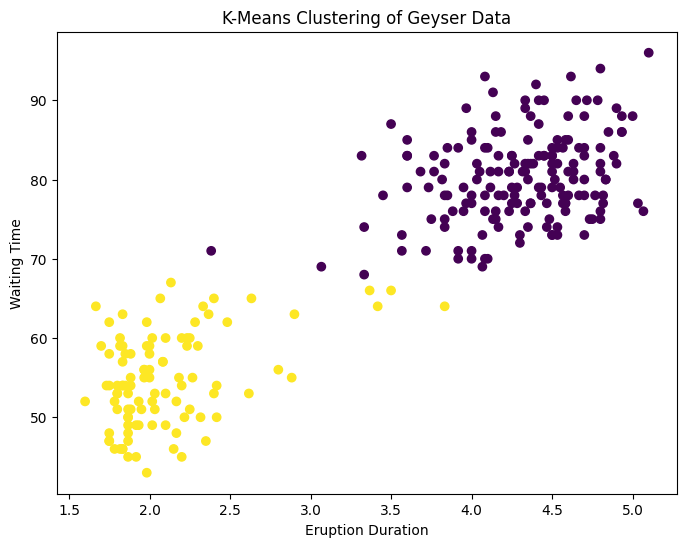

In [ ]:
#scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(
    data['duration'],
    data['waiting'],
    c=data['Cluster']
)

plt.xlabel('Eruption Duration')
plt.ylabel('Waiting Time')
plt.title('K-Means Clustering of Geyser Data')

plt.show()

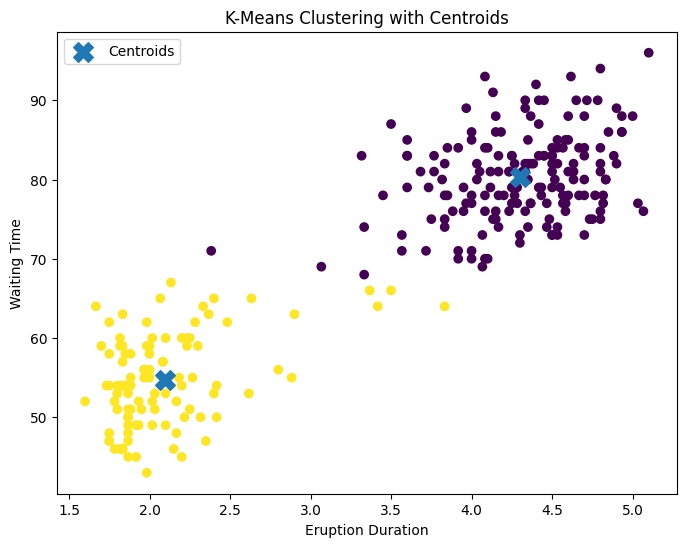

In [ ]:
#scatter plot with centroids
plt.figure(figsize=(8, 6))

# Plot data points
plt.scatter(
    data['duration'],
    data['waiting'],
    c=data['Cluster']
)

# Plot centroids
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel('Eruption Duration')
plt.ylabel('Waiting Time')
plt.title('K-Means Clustering with Centroids')
plt.legend()

plt.show()

In [ ]:
print("Cluster Centroids:")

print(centroids)
print(data['Cluster'].value_counts())

Cluster Centroids:
[[ 4.29793023 80.28488372]
 [ 2.09433    54.75      ]]
Cluster
0    172
1    100
Name: count, dtype: int64


In [ ]:
print("K-Means Clustering Completed")
print("Number of clusters:", kmeans.n_clusters)
print("Centroids:")
print(kmeans.cluster_centers_)

K-Means Clustering Completed
Number of clusters: 2
Centroids:
[[ 4.29793023 80.28488372]
 [ 2.09433    54.75      ]]


### Notebook Summary

**What we did:**
We performed K-Means clustering on the Seaborn "geyser" dataset to group eruptions into distinct clusters based on their duration and waiting time.

**How we did it:**
1. **Setup & Inspection:** Loaded the geyser dataset and inspected its shape, structure, and missing values.
2. **Feature Selection:** Selected the two numeric features: `duration` and `waiting`.
3. **Clustering:** Trained a 2-cluster KMeans model (`n_clusters=2`) and predicted cluster labels for each data point.
4. **Visualization:** Plotted the data points colored by their assigned cluster, overlaying the calculated cluster centroids (the center points of each group).